# Correlation Visualization for R2R Manuscript

2026 version

In [2]:
%cd ../..

/home/bhkuser/bhklab/katy/readii_2_roqc


In [3]:
from damply import dirs
import pandas as pd
import itertools
import plotly.graph_objects as go 
from plotly.subplots import make_subplots
import numpy as np
import re
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

from readii_2_roqc.utils.loaders import load_signature_config, load_dataset_config, load_clinical_data
from readii_2_roqc.utils.analysis import clinical_data_setup, prediction_data_splitting

In [31]:
datasource = "TCIA"
dataset = "NSCLC-Radiomics"

feature_method = "pyradiomics"
feature_settings = "linear_all_images_features"

image_type_a = "original_full"
image_type_b = "shuffled_roi"

In [32]:
dataset_config, dataset_name, full_data_name = load_dataset_config(f"{dataset}_windowed")
split = dataset_config['ANALYSIS']['TRAIN_TEST_SPLIT']['split']

In [33]:
if split:
    clinical_data = clinical_data_setup(dataset_config, 
                                        full_data_name,
                                        split)
    clinical_data = clinical_data[clinical_data.index.notnull()]
    test_samples = pd.Series(clinical_data.index)

In [ ]:
# Save out test samples if needed for other things
# test_samples.to_csv(dirs.PROCDATA / f"{datasource}_{dataset}/test_samples.csv", index=False)

## Big correlation plots

In [ ]:
self_corr_path = dirs.RESULTS / f"{datasource}_{dataset}" / "correlation" / "self" / feature_method / feature_settings / f"{image_type_a}_pearson.csv"
cross_corr_path = dirs.RESULTS / f"{datasource}_{dataset}" / "correlation" / "cross" / feature_method / feature_settings / f"{image_type_b}_vs_{image_type_a}_pearson.csv"

corr_df = pd.read_csv(cross_corr_path, index_col=0)
# cross_corr_df = pd.read_csv(cross_corr_path, index_col=0)

In [49]:
corr_file = Path("correlation") / "cross" / feature_method / feature_settings / f"{image_type_b}_vs_{image_type_a}_pearson.csv"

radcure_correlations = pd.read_csv(dirs.RESULTS / "TCIA_RADCURE_windowed" / corr_file, index_col=0)
hn1_correlations = pd.read_csv(dirs.RESULTS / "TCIA_HEAD-NECK-RADIOMICS-HN1_windowed" / corr_file, index_col=0)
nsclc_correlations = pd.read_csv(dirs.RESULTS / "TCIA_NSCLC-Radiomics_windowed" / corr_file, index_col=0)

corr_df = np.abs((radcure_correlations + hn1_correlations + nsclc_correlations) / 3)

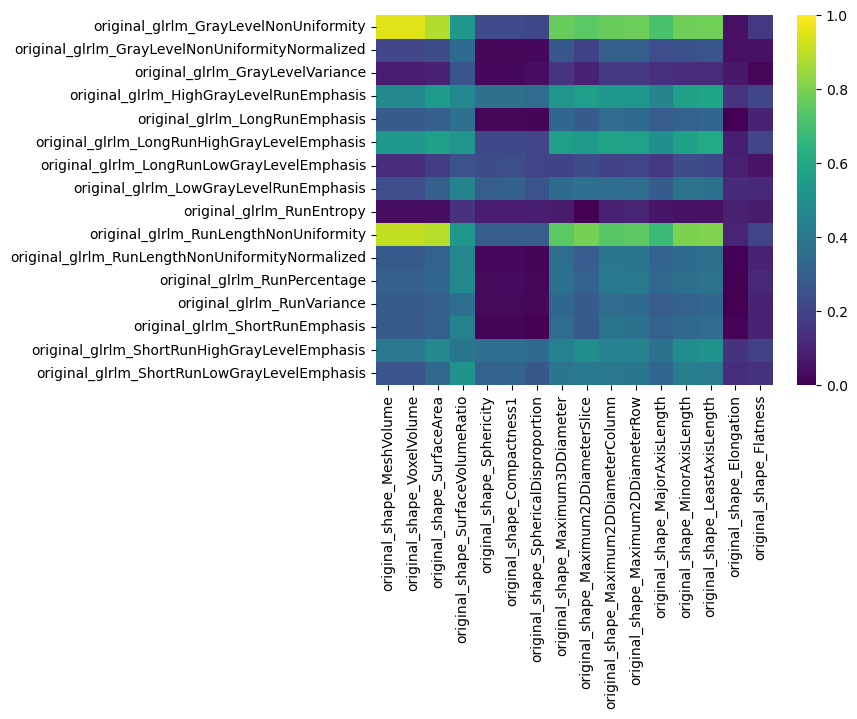

In [50]:
select_df = corr_df.filter(regex="original_glrlm.*", axis=0).filter(regex="original_shape.*", axis=1)
corr_ax = sns.heatmap(select_df,
                        cmap='viridis',
                        vmin=0,
                        vmax=1,
                        xticklabels=True,
                        yticklabels=True)

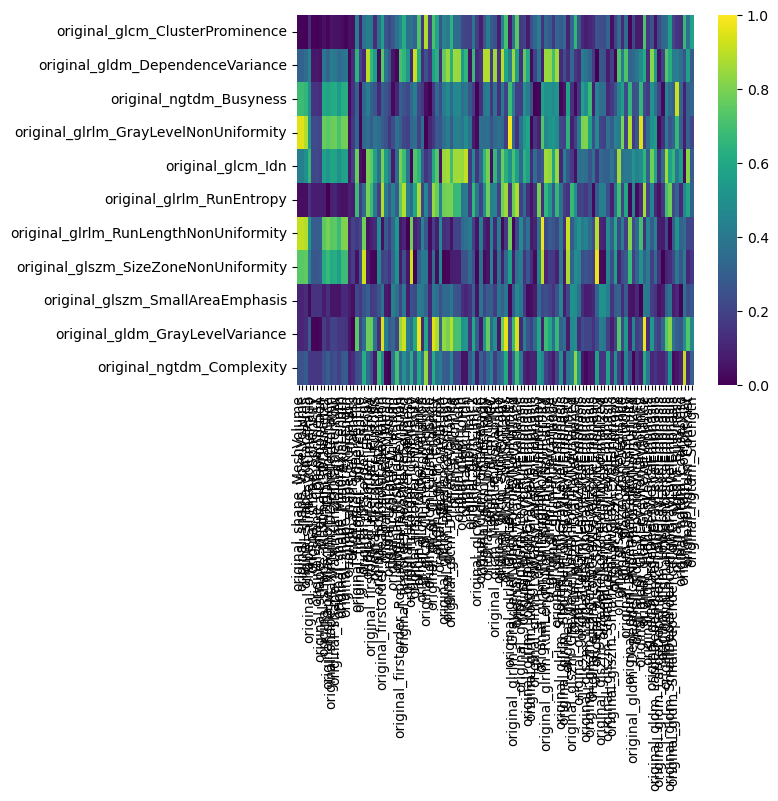

In [55]:
signature_name = 'selection_from_heatmaps'
sig_feats = [
    'original_glcm_ClusterProminence',
    'original_gldm_DependenceVariance',
    'original_ngtdm_Busyness',
    'original_glrlm_GrayLevelNonUniformity',
    'original_glcm_Idn',
    'original_glrlm_RunEntropy',
    'original_glrlm_RunLengthNonUniformity',
    'original_glszm_SizeZoneNonUniformity',
    'original_glszm_SmallAreaEmphasis',
    'original_gldm_GrayLevelVariance',
    'original_ngtdm_Complexity',
]

select_df = corr_df.filter(items=sig_feats, axis=0).filter(regex="original.*", axis=1)

corr_ax = sns.heatmap(select_df,
                        cmap='viridis',
                        vmin=0,
                        vmax=1,
                        xticklabels=True,
                        yticklabels=True)

In [ ]:
signature_name = 'wavelet_selection_from_heatmaps'
sig_feats = [
    'wavelet-HLH_glcm_ClusterProminence',
    'wavelet-HLH_glcm_Idn',
    'wavelet-HLH_glcm_Imc2',
    'wavelet-HLH_glrlm_GrayLevelNonUniformity',
    'wavelet-HLH_glrlm_RunEntropy',
    'wavelet-HLH_glrlm_RunLengthNonUniformity',
    'wavelet-HLH_glszm_SizeZoneNonUniformity',
    'wavelet-HLH_glszm_SmallAreaEmphasis',
    'wavelet-HLH_gldm_DependenceVariance',
    'wavelet-HLH_gldm_GrayLevelVariance',
    'wavelet-HLH_ngtdm_Busyness',
    'wavelet-HLH_ngtdm_Complexity',
]

select_df = corr_df.filter(items=sig_feats, axis=0).filter(regex="original_shape.*", axis=1)

corr_ax = sns.heatmap(select_df,
                        cmap='viridis',
                        vmin=0,
                        vmax=1,
                        xticklabels=True,
                        yticklabels=True)

### Original Features first

In [ ]:
feature_types = corr_df.columns.copy().to_series(name="feature_types")
noshape_feature_types = feature_types.drop(feature_types.filter(regex="original_shape_*", axis=0).to_list())

In [ ]:
noshape_feature_types.str.split("_", n=2)

In [ ]:
feature_classes = [
    "firstorder",
    "glcm",
    "glrlm",
    "glszm",
    "gldm",
    "ngtdm"
]

In [ ]:
class_avg_vol_corr = {}

for feat_class in feature_classes:
    # Get just the specified feature_class features' correlations with the shape features
    subset_features = corr_df.filter(regex="original_shape_*", axis=0).filter(regex=f"{feat_class}_*", axis=1)
    class_avg_vol_corr[feat_class] = subset_features.loc['original_shape_MeshVolume'].abs().mean()

In [ ]:
class_avg_vol_corr

# Features as a function of volume

Borrowed from Velichko et al.

1. Load in the features from each image type 
2. Plot selected features vs. volume as scatter 
3. Colour each image type differently

In [42]:
REGIONS = {'roi'}
PERMUTATIONS = {'randomized', 'sampled', 'shuffled'}

image_types = ['_'.join(itype) for itype in itertools.chain([('original', 'full')],itertools.product(PERMUTATIONS,REGIONS))]

# feature_path = dirs.RESULTS / f"{datasource}_{dataset}" / "features" / feature_method / "original_512_512_n" / feature_settings 

feature_sets = {}

for itype_str in image_types:
    # itype_str = '_'.join(itype)

    itype_feature_list = []

    for dataset in ['HEAD-NECK-RADIOMICS-HN1', 'NSCLC-Radiomics', 'RADCURE']:
        feature_path = dirs.RESULTS / f"{datasource}_{dataset}_windowed" / "features" / feature_method / "original_512_512_n" / feature_settings 
        itype_features = pd.read_csv(feature_path / f"{itype_str}_features.csv", index_col=0)
    
        if dataset == 'RADCURE':
            itype_feature_list.append(itype_features.loc[test_samples])
        else:
            itype_feature_list.append(itype_features)
    
    feature_sets[itype_str] = pd.concat(itype_feature_list)

## Select signature features + MeshVolume

In [43]:
mesh_vol = feature_sets['original_full']['original_shape_MeshVolume']
log_mesh_vol = np.log(mesh_vol)

In [36]:
signature_name = 'test'
sig_feats = ['original_glcm_ClusterProminence']

In [ ]:
# Load config for signature
signature_name = "aerts_original"
signature = load_signature_config(signature_name)

sig_feats = signature.index.to_list()

In [44]:
signature_name = 'selection_from_heatmaps'
sig_feats = [
    'original_glcm_ClusterProminence',
    #original_glcm_Idn',
    'original_glrlm_GrayLevelNonUniformity',
    #'original_glrlm_RunEntropy',
    #'original_glrlm_RunLengthNonUniformity',
    #'original_glszm_SizeZoneNonUniformity',
    #'original_glszm_SmallAreaEmphasis',
    'original_gldm_DependenceVariance',
    #'original_gldm_GrayLevelVariance',
    'original_ngtdm_Busyness',
    #'original_ngtdm_Complexity',
]

In [45]:
# For each feature in the signature, create a dataframe where each column is an image type and the rows are the select feature values for all samples
sig_feature_sets = {}
for feat in sig_feats:
    all_itypes_feat_dict = {itype: feature_set.loc[:,feat] for itype,feature_set in feature_sets.items()}
    select_feat_df = pd.DataFrame.from_dict(all_itypes_feat_dict).sort_index(axis=1)
    # replace non_roi with background
    select_feat_df = select_feat_df.rename(columns=lambda x: re.sub('non_roi', 'background',x))
    sig_feature_sets[feat] = select_feat_df

In [39]:
colours = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']
region = 'roi'
image_types=[f'randomized_{region}', f'sampled_{region}', f'shuffled_{region}', 'original_full']

plot_vol = mesh_vol

fig = make_subplots(
    rows=1, cols=4,
    subplot_titles=(sig_feats),
)

show_legend = True
for idx, feat_name in enumerate(sig_feature_sets.keys()):
    plot_feat = sig_feature_sets[feat_name]
    
    # Plot permutation features
    for col_idx, itype in enumerate(image_types):
        fig.add_trace(
            go.Scatter(
                x=plot_vol,
                y=plot_feat[itype],
                mode='markers',
                marker=dict(
                    size=6,
                    color=colours[col_idx]
                ),
                opacity=0.8,
                name=itype,
               legendgroup='group1',
               showlegend=show_legend
        ),
        row=1,
        col=idx+1
    )
    show_legend = False

fig.update_layout(
    title=signature_name,
    title_subtitle=dict(
        text=dataset),
    width=2500,
    height=550,
)

fig.update_xaxes(title_text="Mesh_Volume", title_font=dict(size=12))
fig.update_annotations(font_size=14)
fig.show()

In [46]:
import plotly.express as px 

def plot_feat_vs_volume(plot_feature_df:pd.DataFrame,
                        plot_vol:pd.Series,
                        image_types:list,
                        feature_name:str | None = None,
                        y_min:int | float | None = None,
                        y_max:int | float | None = None,
                        log_vol:bool = False,
                        log_feat:bool = False,
                        ) -> go.Figure:
    # colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3', '#FF6692', '#B6E880', '#FF97FF', '#FECB52']

    fig = go.Figure()

    for idx, itype in enumerate(image_types):
        fig.add_trace(
            go.Scatter(
                x=plot_vol,
                y=plot_feature_df[itype],
                mode='markers',
                marker=dict(
                    size=6,
                ),
                name=itype,
                opacity=0.8
            )
        )

    fig.update_layout(
        title=feature_name,
        height=700,
        width=900
    )

    if log_vol:
        fig.update_xaxes(type="log")

    fig.update_yaxes(range=[y_min,y_max])
    if log_feat:
        fig.update_yaxes(type="log")

    return fig

In [47]:
region = 'roi'
image_types=[f'randomized_{region}', f'sampled_{region}', f'shuffled_{region}', 'original_full']
log_vol = True
log_feat = True

fig_list = []
for idx, feature in enumerate(sig_feats):

    plot_feat_df = sig_feature_sets[feature]
   
    log_fig = plot_feat_vs_volume(plot_feat_df, mesh_vol, image_types, feature, log_vol = log_vol, log_feat=log_feat)
    log_fig.update_layout(
        title_subtitle=dict(text=dataset)
    )
    log_fig.show()

    # fig_list.append(log_fig)
    # fig_list.append(sns_fig)

In [ ]:
fig = make_subplots(
    rows=3, cols=4,
    # x_title='Mesh Volume',
    subplot_titles=(sig_feats))


show_legend = True
for idx, feat_name in enumerate(sig_feature_sets.keys()):
    plot_feat = sig_feature_sets[feat_name]

    full_feat_set = plot_feat.columns.str.contains('full')
    roi_feat_set = plot_feat.columns.str.contains('roi')
    background_feat_set = plot_feat.columns.str.contains('background')

    # Set first bool in roi and background list to True so 'original_full' is plotted
    roi_feat_set[0] = True 
    background_feat_set[0] = True

    for row_idx, feat_subset in enumerate([full_feat_set, roi_feat_set, background_feat_set]):
        # Plot the full region negative control points
        for itype in plot_feat.loc[:,feat_subset]:
            fig.add_trace(
                go.Scatter(
                    x = mesh_vol,
                    y = plot_feat[itype],
                    mode='markers',
                    marker=dict(
                        size=6
                    ),
                    name=itype,
                    legendgroup='group2',
                    showlegend=show_legend
                    ),
                row=row_idx+1,
                col=idx+1,
            )
    

    
    if show_legend:
        show_legend=False

fig.update_layout(
    title=signature_name,
    title_subtitle=dict(
        text=dataset),
    width=2500,
    height=550
    
)

fig.update_xaxes(title_text="Mesh_Volume", title_font=dict(size=12))
fig.update_annotations(font_size=14)
fig.show()

In [ ]:
fig = make_subplots(
    rows=1, cols=4,
    subplot_titles=(sig_feats))

show_legend=True

for idx, feat_name in enumerate(sig_feature_sets.keys()):
    plot_feat = sig_feature_sets[feat_name]

    for itype in ['original_full']:
        fig.add_trace(
            go.Scatter(
                x = mesh_vol,
                y = plot_feat[itype],
                mode='markers',
                name=itype,
                marker=dict(
                    color='#636EFA'
                ),
                legendgroup='group1',
                showlegend=show_legend
                ),
            row=1,
            col=idx+1
        )
        if show_legend:
            show_legend=False

fig.update_annotations(font_size=12)
fig.show()

In [ ]:
# broken SNS scatter code

scatter_fig, scatter_ax = plt.subplots(1,1)

melt_vol_df = pd.melt(plot_vol, value_vars=image_types)
melt_feature_df = pd.melt(plot_feature_df, value_vars=image_types)

if log_vol:
    melt_vol_df['value'] = np.log(melt_vol_df['value'])

if log_feat:
    melt_feature_df['value'] = np.log(melt_feature_df['value'])

merged_plot_df = melt_vol_df.merge(melt_feature_df, on=['variable'], suffixes=('_vol', '_feat'))

sns.scatterplot(
    data = merged_plot_df,
    x='value_vol',
    y='value_feat',
    palette=px.colors.qualitative.Plotly,
    hue='variable',
    ax=scatter_ax
    )

scatter_ax.set_title(feature_name)